# ABC/FMS And Layout Evidence

Implements the supervisor report: cumulative issued volume for ABC, issue frequency for FMS, both calculated within RM/PM physical subtypes.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

In [2]:
classes=pd.read_csv(OUT/'material_classifications.csv.gz')
thresholds=pd.read_csv(OUT/'classification_thresholds.csv.gz')
display(thresholds)
display(pd.crosstab(classes.abc_class, classes.fms_class, margins=True))

,material_type,category,abc_a_cumulative_max,abc_b_cumulative_max,fms_slow_upper,fms_fast_lower,method,observation_start,observation_end,source_rows
0,packaging_material,BOTTLE,0.8,0.95,12.0000,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,4
1,packaging_material,CAP,0.8,0.95,10.6667,11.3333,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,3
2,packaging_material,CARTON,0.8,0.95,12.0000,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,5
3,packaging_material,CORR_BOX,0.8,0.95,12.0000,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,4
4,packaging_material,INNER_LINER,0.8,0.95,11.0000,11.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,1
5,packaging_material,INSERT,0.8,0.95,11.0000,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,7
6,packaging_material,JAR,0.8,0.95,12.0000,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,1
7,packaging_material,NECK_TAG,0.8,0.95,12.0000,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,1
8,packaging_material,POUCH,0.8,0.95,11.6667,12.0000,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,3
9,packaging_material,TUBE,0.8,0.95,11.3333,11.6667,ABC_CUMULATIVE_USAGE_AND_1D_NATURAL_BREAKS,2025-01-01,2025-12-01,2


fms_class,F,M,S,All
abc_class,,,,
A,27,1,1,29
B,16,1,0,17
C,23,3,8,34
All,66,5,9,80


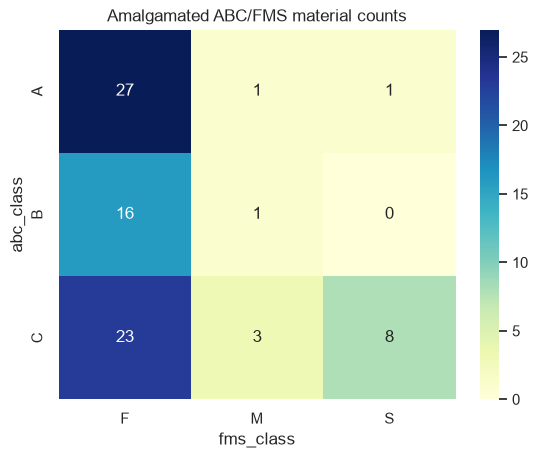

In [3]:
matrix=classes.pivot_table(index='abc_class',columns='fms_class',values='material_id',aggfunc='count',fill_value=0)
sns.heatmap(matrix,annot=True,fmt='g',cmap='YlGnBu'); plt.title('Amalgamated ABC/FMS material counts'); plt.show()

In [4]:
for key, group in classes.groupby(['material_type','category']):
    if len(group)>=5:
        ordered=group.sort_values('issue_volume_12m',ascending=False)
        assert ordered.cumulative_usage_share.is_monotonic_increasing
print('All subtype cumulative-volume classifications are monotonic and threshold evidence is persisted.')

All subtype cumulative-volume classifications are monotonic and threshold evidence is persisted.
